# Replication: Baron (1982) — Regulating a Monopolist with Unknown Costs (Python)

## Goal of this notebook
We replicate the optimal regulation policy characterized in Baron (1982) by:
1) computing the virtual/adjusted cost function,
2) "ironing" it into a monotone function,
3) constructing the optimal policy (price, quantity, shutdown, subsidy),
4) simulating outcomes over parameters and distributions.

## What we replicate from the paper
- Cost: $C(q,θ) = (c_0 + c_1 θ) q + (k_0 + k_1 θ) \text{ for } q>0$, and $C(0,θ)=0$. 
- Demand: $P(q) = V'(q)$. 
- Virtual cost: $z_a(θ) = θ + (1-a) F(θ)/f(θ)$. 
- Ironing construction (CDF-space convexification): eqs (19)-(23). 
- Policy rules: eqs (25)-(28). 

## Notebook structure
1. Imports and numerical helpers
2. Model primitives (demand, value, costs)
3. Type distributions F,f and numerical inverse CDF
4. Virtual cost z_a(θ) and ironing to get z_fa(θ)
5. Optimal policy mapping (p,q,r,π,s)
6. Replication check using the paper’s worked example
7. Simulation loops → pandas DataFrame
8. Figures + economic interpretation helpers
9. Extension: how distribution shape affects ironing ("bunching") and outcomes


In [ ]:
!pip install numpy pandas matplotlib scipy

In [ ]:
# Core numerical stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.optimize import minimize_scalar
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

In [2]:


def cumtrapz(y, x):
    """
    LaTeX (raw):
        \\int y(x) dx  \\approx  \\sum_{i=1}^n \\frac{(y_i + y_{i-1})}{2} (x_i - x_{i-1})
    """
    # cumulative trapezoid integral with same length as x (starts at 0)
    y = np.asarray(y)
    x = np.asarray(x)
    out = np.zeros_like(x, dtype=float)
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * dx)
    return out


def safe_div(num, den, eps=1e-12):
    """
    LaTeX (raw):
        \\frac{num}{den} \\approx \\frac{num}{\\max(den, \\varepsilon)}
    """
    return np.asarray(num) / np.maximum(np.asarray(den), eps)


def monotone_decreasing(x, y):
    """
    Quick diagnostic: checks if y(x) is weakly decreasing in x.
    """
    idx = np.argsort(x)
    y_sorted = np.asarray(y)[idx]
    return np.all(np.diff(y_sorted) <= 1e-10)


# 1. Model primitives

## Demand / value
The paper uses a general concave value function $V(q)$, with inverse demand $P(q)=V'(q)$.

In code, we implement demand as:
- `P(q)` = inverse demand (price as a function of quantity)
- `V(q)` = integral of P(q)

We will include:
1) Linear inverse demand: $P(q)=A - B q$
2) Isoelastic inverse demand: $P(q)=A q^{-1/ε} (ε>1)$

## Costs
The firm cost is bilinear in (q,θ):
$C(q,θ) = (c_0 + c_1 θ) q + (k_0 + k_1 θ)  \text{ for } q>0;  C(0,θ)=0.$ 

We'll code it as `cost(q, theta, params)` and use it to compute profits and subsidies.


In [3]:
def P_linear(q, A, B):
    r"""
    LaTeX (raw):
        P(q) = A - B q
    """
    q = np.asarray(q)
    return A - B * q


def V_linear(q, A, B):
    r"""
    LaTeX (raw):
        V(q) = \int_0^q (A - B t)\,dt = A q - \frac{B}{2} q^2
    """
    q = np.asarray(q)
    return A * q - 0.5 * B * q**2


def P_isoelastic(q, A, eps):
    r"""
    LaTeX (raw):
        P(q) = A q^{-1/\varepsilon}, \quad \varepsilon>1
    """
    q = np.asarray(q)
    q = np.maximum(q, 1e-12)  # avoid division by zero
    return A * q ** (-1.0 / eps)


def V_isoelastic(q, A, eps):
    r"""
    LaTeX (raw):
        V(q) = \int_0^q A t^{-1/\varepsilon} dt
             = A \frac{\varepsilon}{\varepsilon-1} q^{(\varepsilon-1)/\varepsilon} \quad (\varepsilon \ne 1)
    """
    q = np.asarray(q)
    q = np.maximum(q, 1e-12)
    return A * (eps / (eps - 1.0)) * q ** ((eps - 1.0) / eps)


def cost(q, theta, c0, c1, k0, k1):
    r"""
    LaTeX (raw):
        C(q,\theta) =
        \begin{cases}
        (c_0 + c_1 \theta) q + (k_0 + k_1 \theta) & q>0 \\
        0 & q=0
        \end{cases}
    """
    q = np.asarray(q)
    theta = np.asarray(theta)
    C = (c0 + c1 * theta) * q + (k0 + k1 * theta)
    return np.where(q > 0, C, 0.0)


# 2. Quantity from a regulated price

Policy equation (26) imposes that the chosen quantity satisfies:
$P(q(θ)) = p(θ)$. 

Computationally, we can obtain q in two equivalent ways:
1) Root/fixed-point: solve $P(q) - p = 0$
2) Optimization: q solves $\max_{q>=0} [V(q) - p q]$, whose FOC is $V'(q)=P(q)=p$.

We'll implement the optimization method (good for the assignment requirement),
and provide a fallback grid-search if SciPy isn't available.


In [5]:
def solve_q_from_price(V_func, p, q_max, V_args=()):
    r"""
    LaTeX (raw):
        q(p) = \arg\max_{q \in [0,q_{\max}]} \left[ V(q) - p q \right]
    """
    # Objective is negative surplus because we minimize
    def obj(q):
        return -(V_func(q, *V_args) - p * q)

    # Use SciPy if available; else do a simple grid search fallback
    if SCIPY_OK:
        res = minimize_scalar(obj, bounds=(0.0, q_max), method="bounded")
        return float(res.x)
    else:
        # coarse fallback grid (increase points if needed)
        grid = np.linspace(0.0, q_max, 2000)
        vals = -(V_func(grid, *V_args) - p * grid)
        return float(grid[np.argmin(vals)])


# 3. Distribution of θ

The type θ lies on $[θ_0, θ_1]$ with CDF $F(θ)$ and density $f(θ)$.

The virtual cost uses $F/f$, so we must be able to compute both on a grid.

We also need an approximate inverse CDF $F^{-1}(φ)$ to implement ironing in "CDF space"
(eqs. 19-23). 

We'll implement:
- Uniform $[θ_0,θ_1]$ (baseline replication)
- A "mixture of uniforms" on the same support (to create non-monotone virtual costs and trigger ironing)
For generality, we compute a numeric inverse CDF using interpolation on a fine θ-grid.


In [6]:
class DistUniform:
    def __init__(self, theta0, theta1):
        self.theta0 = float(theta0)
        self.theta1 = float(theta1)

    def cdf(self, theta):
        r"""
        LaTeX (raw):
            F(\theta) =
            \begin{cases}
            0 & \theta \le \theta_0 \\
            (\theta-\theta_0)/(\theta_1-\theta_0) & \theta_0<\theta<\theta_1 \\
            1 & \theta \ge \theta_1
            \end{cases}
        """
        t = np.asarray(theta)
        F = (t - self.theta0) / (self.theta1 - self.theta0)
        return np.clip(F, 0.0, 1.0)

    def pdf(self, theta):
        r"""
        LaTeX (raw):
            f(\theta) =
            \begin{cases}
            1/(\theta_1-\theta_0) & \theta_0 \le \theta \le \theta_1 \\
            0 & \text{otherwise}
            \end{cases}
        """
        t = np.asarray(theta)
        out = np.zeros_like(t, dtype=float)
        inside = (t >= self.theta0) & (t <= self.theta1)
        out[inside] = 1.0 / (self.theta1 - self.theta0)
        return out


class DistMixtureUniform:
    """
    Mixture of two uniforms on the same support [theta0, theta1] but with different "tilts"
    implemented via piecewise densities. This is a simple way to create shapes where F/f varies.
    """
    def __init__(self, theta0, theta1, w=0.5, split=0.5):
        self.theta0 = float(theta0)
        self.theta1 = float(theta1)
        self.w = float(w)          # mixture weight for left-heavy component
        self.split = float(split)  # split point in normalized support [0,1]

    def pdf(self, theta):
        r"""
        LaTeX (raw):
            f(\theta) = w f_1(\theta) + (1-w) f_2(\theta)
        where each f_i is piecewise-constant on [θ0,θ1].
        """
        t = np.asarray(theta)
        out = np.zeros_like(t, dtype=float)
        inside = (t >= self.theta0) & (t <= self.theta1)
        if not np.any(inside):
            return out

        # Normalize to x in [0,1]
        x = (t[inside] - self.theta0) / (self.theta1 - self.theta0)

        # Component 1: higher density on left side
        # Component 2: higher density on right side
        # We choose constants so each integrates to 1 over [0,1].
        s = np.clip(self.split, 1e-6, 1 - 1e-6)

        f1 = np.where(x <= s, 1.5 / s, 0.5 / (1 - s))   # integrates to 1
        f2 = np.where(x <= s, 0.5 / s, 1.5 / (1 - s))   # integrates to 1

        # Convert density on x to density on theta (Jacobian 1/(theta1-theta0))
        out_inside = (self.w * f1 + (1 - self.w) * f2) / (self.theta1 - self.theta0)
        out[inside] = out_inside
        return out

    def cdf(self, theta):
        r"""
        LaTeX (raw):
            F(\theta) = \int_{\theta_0}^{\theta} f(t)\,dt
        """
        # Numerical CDF via integrating pdf on a fine grid and interpolating
        t = np.asarray(theta)
        grid = np.linspace(self.theta0, self.theta1, 5000)
        fgrid = self.pdf(grid)
        Fgrid = cumtrapz(fgrid, grid)
        # Normalize to ensure F(theta1)=1 exactly (numerical stability)
        Fgrid = Fgrid / max(Fgrid[-1], 1e-12)

        # Interpolate with boundary clipping
        return np.interp(np.clip(t, self.theta0, self.theta1), grid, Fgrid, left=0.0, right=1.0)


def inverse_cdf_numeric(dist, phi_grid, theta_grid=None):
    r"""
    LaTeX (raw):
        F^{-1}(\phi) \approx \text{interp}\left(\phi; \{F(\theta_i)\}, \{\theta_i\}\right)
    """
    phi_grid = np.asarray(phi_grid)
    if theta_grid is None:
        theta0 = getattr(dist, "theta0", 0.0)
        theta1 = getattr(dist, "theta1", 1.0)
        theta_grid = np.linspace(theta0, theta1, 8000)

    F_vals = dist.cdf(theta_grid)
    # Enforce monotonicity numerically (CDF should be monotone, but small noise can happen)
    F_vals = np.maximum.accumulate(F_vals)

    # Invert by interpolation: theta = F^{-1}(phi)
    theta_of_phi = np.interp(np.clip(phi_grid, 0.0, 1.0), F_vals, theta_grid, left=theta_grid[0], right=theta_grid[-1])
    return theta_of_phi


# 4. Virtual cost and ironing (the computational core)

The paper defines the "virtual/adjusted cost":
$z_a(θ) = θ + (1-a) F(θ)/f(θ).$ 

But the optimal policy requires a monotone version $z_{fa}(θ)$, constructed by:
1) mapping to $φ = F(θ)$,
2) defining $h_a(φ)=z_a(F^{-1}(φ))$ and $H_a(φ)=∫_0^φ h_a(t) dt$, 
3) taking the highest convex function below H_a (convex minorant),
4) differentiating it to get $\hat h_a(φ)$,
5) mapping back $z_{fa}(θ)=\hat h_a(F(θ))$. 

In code:
- we discretize $φ$ on [0,1],
- compute $θ(φ)=F^{-1}(φ)$,
- compute $z_a$ on that grid,
- integrate to get $H_a$,
- compute the convex minorant using a stack/hull algorithm,
- compute slopes = derivative,
- interpolate back to θ-grid.

This step is where "bunching" appears: flat segments of z_fa(θ) imply different θ get the same effective cost, hence same p and q.


In [7]:
def virtual_cost(theta, dist, a):
    r"""
    LaTeX (raw):
        z_a(\theta) = \theta + (1-a)\frac{F(\theta)}{f(\theta)}
    """
    F = dist.cdf(theta)
    f = dist.pdf(theta)
    return theta + (1.0 - a) * safe_div(F, f)


def convex_minorant_1d(x, y):
    r"""
    LaTeX (raw):
        \widehat{H} = \text{conv}(H) = \text{highest convex function below } H
    Notes:
        We compute the convex minorant of points (x_i, y_i) with x increasing.
        Convexity implies slopes are nondecreasing.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Each "segment" in the hull will be represented by (x_left, y_left, x_right, y_right)
    # We'll build a list of breakpoints in terms of indices.
    idx = []  # stack of indices of breakpoints
    for i in range(len(x)):
        idx.append(i)
        # While last three points violate convexity (slope decreasing), merge the middle one out
        while len(idx) >= 3:
            i1, i2, i3 = idx[-3], idx[-2], idx[-1]
            s12 = (y[i2] - y[i1]) / (x[i2] - x[i1] + 1e-18)
            s23 = (y[i3] - y[i2]) / (x[i3] - x[i2] + 1e-18)
            if s23 < s12 - 1e-14:
                # remove i2 (middle) to restore nondecreasing slopes
                idx.pop(-2)
            else:
                break

    # Build the convex minorant values by linear interpolation between breakpoints
    y_hat = np.zeros_like(y)
    for j in range(len(idx) - 1):
        left = idx[j]
        right = idx[j + 1]
        # line segment between (x[left], y[left]) and (x[right], y[right])
        slope = (y[right] - y[left]) / (x[right] - x[left] + 1e-18)
        y_hat[left:right + 1] = y[left] + slope * (x[left:right + 1] - x[left])

    return y_hat, idx


def iron_virtual_cost(dist, a, n_phi=2001):
    r"""
    LaTeX (raw):
        \phi = F(\theta), \quad h_a(\phi)=z_a(F^{-1}(\phi)),
        \quad H_a(\phi)=\int_0^\phi h_a(t)\,dt,
        \quad \widehat{H}_a = \text{conv}(H_a),
        \quad \widehat{h}_a(\phi)=\frac{d}{d\phi}\widehat{H}_a(\phi),
        \quad z_{fa}(\theta)=\widehat{h}_a(F(\theta)).
    """
    # φ-grid in [0,1]
    phi = np.linspace(0.0, 1.0, n_phi)

    # θ(φ) via numeric inverse CDF
    theta_phi = inverse_cdf_numeric(dist, phi)

    # h_a(φ) = z_a(θ(φ))
    z_phi = virtual_cost(theta_phi, dist, a)  # this is h_a(φ) evaluated on φ-grid

    # H_a(φ) = ∫_0^φ h_a(t) dt
    H_phi = cumtrapz(z_phi, phi)

    # Convex minorant of H
    H_hat, break_idx = convex_minorant_1d(phi, H_phi)

    # Derivative (piecewise slope) gives \hat h_a(φ)
    # We compute slopes between adjacent φ points of the convexified curve
    h_hat = np.zeros_like(phi)
    dphi = np.diff(phi)
    dH = np.diff(H_hat)
    slopes = dH / (dphi + 1e-18)
    h_hat[1:] = slopes
    h_hat[0] = slopes[0] if len(slopes) > 0 else z_phi[0]

    # For nicer behavior, smooth the derivative very lightly by averaging neighbors (optional)
    h_hat = 0.5 * (h_hat + np.r_[h_hat[0], h_hat[:-1]])

    return {
        "phi": phi,
        "theta_phi": theta_phi,
        "z_phi": z_phi,     # pre-ironing h_a(φ)
        "H_phi": H_phi,     # pre-ironing integral
        "H_hat": H_hat,     # convexified integral
        "h_hat": h_hat,     # ironed h(φ)
        "break_idx": break_idx
    }


def z_fa_on_theta_grid(theta_grid, dist, ironing_out):
    r"""
    LaTeX (raw):
        z_{fa}(\theta)=\widehat{h}_a(F(\theta))
    """
    # Compute φ = F(θ)
    phi_theta = dist.cdf(theta_grid)
    # Interpolate \hat h_a(φ) at φ=F(θ)
    zfa = np.interp(phi_theta, ironing_out["phi"], ironing_out["h_hat"])
    return zfa


# 5. Construct the optimal policy

Given $z_{fa}(θ)$, the theorem gives the policy:
- $p(θ)=c_0 + c_1 z_fa(θ)$  (eq. 25) 
- $q(θ)$ solves $P(q)=p(θ)$ (eq. 26) 
- $r(θ)=1$ if consumer surplus at price $p$ covers the "effective fixed cost" (eq. 27) 

Subsidies are pinned down by incentive constraints. A numerically stable way:
1) compute the profit schedule $π(θ)$ from the envelope identity:
   $dπ/dθ = - r(θ)(c_1 q(θ)+k_1)$,
   and set $π(θ_1)=0$ (minimal rents).
2) then back out $s(θ)$ using the accounting identity for $π(θ)$.

This avoids fragile direct implementation of the full closed form for $s(θ)$.


In [11]:
def compute_policy(
    theta_grid,
    dist,
    a,
    demand_kind,
    demand_params,
    cost_params,
    q_max=50.0,
    n_phi=2001,
):
    r"""
    LaTeX (raw):
        p(\theta)=c_0+c_1 z_{fa}(\theta)
        \quad,\quad
        q(\theta)=\arg\max_{q\in[0,q_{\max}]}[V(q)-p(\theta)q]
        \quad,\quad
        r(\theta)=\mathbf{1}\{V(q)-p q \ge k_0+k_1 z_{fa}(\theta)\}
    """
    theta_grid = np.asarray(theta_grid, dtype=float)
    c0, c1, k0, k1 = cost_params

    # 1) Ironing step to get z_fa(θ)
    ironing = iron_virtual_cost(dist, a, n_phi=n_phi)
    zfa = z_fa_on_theta_grid(theta_grid, dist, ironing)

    # 2) Price schedule: p(θ)=c0 + c1 z_fa(θ)
    p = c0 + c1 * zfa

    # 3) Quantity schedule via optimization: q(θ)=argmax V(q)-p q
    if demand_kind == "linear":
        A, B = demand_params
        V_func = V_linear
        V_args = (A, B)
    elif demand_kind == "isoelastic":
        A, eps = demand_params
        V_func = V_isoelastic
        V_args = (A, eps)
    else:
        raise ValueError("Unknown demand_kind")

    q = np.zeros_like(theta_grid)
    for i in range(len(theta_grid)):
        # Solve the consumer problem given regulated price p[i]
        q[i] = solve_q_from_price(V_func, p[i], q_max=q_max, V_args=V_args)

    # 4) Shutdown rule using consumer surplus:
    # CS(θ)=V(q(θ)) - p(θ) q(θ)
    CS = V_func(q, *V_args) - p * q

    # Effective fixed cost threshold: k0 + k1 z_fa(θ)
    fixed_eff = k0 + k1 * zfa

    # r(θ) = 1 if CS >= fixed_eff else 0
    r = (CS >= fixed_eff).astype(float)

    # 5) Profit schedule from envelope: π(θ1)=0, π(θ)=∫_θ^{θ1} r(t)(c1 q(t)+k1) dt
    # We'll approximate via backward cumulative integration on θ-grid.
    integrand = r * (c1 * q + k1)
    # Sort by theta increasing (should already be increasing)
    idx = np.argsort(theta_grid)
    th = theta_grid[idx]
    integrand_sorted = integrand[idx]

    # Backward integral: for each i, pi[i] = ∫_{th[i]}^{th[-1]} integrand(t) dt
    # We'll compute forward cumulative and subtract.
    forward_int = cumtrapz(integrand_sorted, th)
    total = forward_int[-1]
    pi_sorted = total - forward_int  # ensures pi(theta1)=0
    # Re-map to original order
    pi = np.empty_like(pi_sorted)
    pi[idx] = pi_sorted

    # 6) Subsidy from accounting identity:
    # π = [p q - (c0 + c1 θ) q - (k0 + k1 θ)] r + s
    theta = theta_grid
    variable_profit = (p * q - (c0 + c1 * theta) * q - (k0 + k1 * theta)) * r
    s = pi - variable_profit

    return {
        "theta": theta_grid,
        "za": virtual_cost(theta_grid, dist, a),
        "zfa": zfa,
        "p": p,
        "q": q,
        "CS": CS,
        "r": r,
        "pi": pi,
        "s": s,
        "ironing": ironing
    }


# 6. Replication check: the paper’s worked example (unit test)

The paper gives a special case ("known fixed costs"):
$k_1=c_0=0$, $c_1=1$ so $C(q,θ)=k_0 + θ q$, and θ ~ Uniform $[θ_0,θ_1].$

In that case, the optimal price schedule is explicitly:
$p(θ) = (2-a)θ - (1-a)θ_0.$ 

We'll:
1) run our general pipeline,
2) compute p(θ) numerically,
3) compare to the analytic formula and print max error.
If max error is tiny (numerical tolerance), our pipeline is correctly replicating the core theorem.


In [14]:
# --- Parameters for the replication test ---
theta0, theta1 = 1.0, 3.0
dist = DistUniform(theta0, theta1)

# Cost: c0=0, c1=1, k0>0, k1=0
cost_params = (0.0, 1.0, 0.5, 0.0)

# Demand from the example: q = a - b p  => inverse demand P(q) = (a - q)/b.
# We'll parameterize inverse demand as P(q)=A - B q with A=a/b, B=1/b.
a_lin, b_lin = 10.0, 1.0
A, B = a_lin / b_lin, 1.0 / b_lin

theta_grid = np.linspace(theta0, theta1, 2001)

# Pick a value for 'a' (regulator weight). We'll test multiple.
a_list = [0.0, 0.25, 0.5, 0.75, 1.0]

errors = []
for a_weight in a_list:
    out = compute_policy(
        theta_grid=theta_grid,
        dist=dist,
        a=a_weight,
        demand_kind="linear",
        demand_params=(A, B),
        cost_params=cost_params,
        q_max=a_lin,   # natural upper bound for linear demand
        n_phi=2001
    )

    # Analytic formula from the paper for this case:
    # p(θ) = (2-a)θ - (1-a)θ0
    p_analytic = (2.0 - a_weight) * theta_grid - (1.0 - a_weight) * theta0
    max_err = np.max(np.abs(out["p"] - p_analytic))
    errors.append((a_weight, max_err))

pd.DataFrame(errors, columns=["a", "max_abs_error_in_p(theta)"])


,a,max_abs_error_in_p(theta)
0,0.00,0.00200
1,0.25,0.00175
2,0.50,0.00150
3,0.75,0.00125
4,1.00,0.00100


### Replication check (unit test): closed-form price schedule vs numerical algorithm

In the “known fixed costs + Uniform type” special case, the paper provides a **closed-form** expression for the optimal regulated price schedule:

$$
p_{\text{analytic}}(\theta)=(2-a)\theta-(1-a)\theta_0.
$$
We use this as a benchmark.

Independently, our Python implementation computes a price schedule $(p_{\text{code}}(\theta))$ using the **general theorem pipeline**:
1) compute virtual cost $(z_a(\theta))$,
2) apply ironing to obtain the monotone $(z_{fa}(\theta))$,
3) map to prices via $(p(\theta)=c_0+c_1 z_{fa}(\theta))$.

For each value of $(a)$ and each $(\theta)$ on a fine grid, we compare the two schedules and report:
$$
\max_{\theta}\left|p_{\text{code}}(\theta)-p_{\text{analytic}}(\theta)\right|.
$$
The maximum absolute differences are very small (around $(10^{-3})$), which is consistent with **numerical discretization error** from using finite grids, numerical integration, and interpolation. This provides strong evidence that our code correctly replicates the paper’s closed-form solution in the case where an analytical benchmark is available.


# 7. Incentive compatibility diagnostics (truth-telling equilibrium check)

Up to now, we constructed a regulatory mechanism (policy schedule) using the theorem pipeline:
- compute virtual cost,
- iron it,
- map to prices, quantities, shutdown, and subsidies.

The theory implies the resulting mechanism is **incentive compatible**: a firm with true type θ should find it optimal to report θ truthfully.

## What “truth-telling equilibrium” means here
For a true type θ and a reported type $\hat{θ}$, the firm's profit is:

$$
\pi(\theta,\hat\theta)
=
\left[p(\hat\theta)q(\hat\theta) - (c_0+c_1\theta)q(\hat\theta) - (k_0+k_1\theta)\right]r(\hat\theta) + s(\hat\theta).
$$

Truth-telling is an equilibrium if, for every θ,
$$
\pi(\theta,\theta)\ge \pi(\theta,\hat\theta)\quad \forall \hat\theta.
$$

## How we test it numerically
On a discrete grid of types:
1) For each true $θ_i$, compute profits for all possible reports $\hat{θ}_j$.
2) Find the best report $BR(θ_i)=\argmax_j π(θ_i,\hat{θ}_j)$.
3) Compute the deviation gain:

$$
\Delta(\theta_i)=\max_j \pi(\theta_i,\hat\theta_j)-\pi(\theta_i,\theta_i).
$$

If the mechanism is IC, $Δ(θ_i)$ should be $≤ 0$ (up to a small numerical tolerance).

## Why this step is useful
- It confirms our numerical implementation produces a truthful equilibrium (not just “it should”).
- It lets us study when IC breaks due to numerical issues (coarse grids, interpolation) or model changes (distribution shapes creating strong ironing/bunching).


In [46]:
def profit_matrix_true_report(theta_true_grid, policy, cost_params):
    r"""
    LaTeX (raw):
        \pi(\theta,\hat\theta)
        =
        \left(p(\hat\theta)q(\hat\theta) - (c_0+c_1\theta)q(\hat\theta) - (k_0+k_1\theta)\right) r(\hat\theta)
        + s(\hat\theta)
    Returns:
        Pi: matrix with shape (n_true, n_report)
            rows = true theta, cols = reported theta
    """
    c0, c1, k0, k1 = cost_params

    # Arrays indexed by report type (theta_report grid used in policy)
    p = np.asarray(policy["p"])
    q = np.asarray(policy["q"])
    r = np.asarray(policy["r"])
    s = np.asarray(policy["s"])

    # Broadcast true theta across report dimension
    theta_true = np.asarray(theta_true_grid).reshape(-1, 1)  # (n_true, 1)

    # Profit if true type is theta_true but the mechanism applies report-indexed allocations
    Pi = (p * q - (c0 + c1 * theta_true) * q - (k0 + k1 * theta_true)) * r + s
    return Pi


def check_incentive_compatibility(policy, theta_grid, cost_params, tol=1e-6, use_subgrid=401):
    r"""
    LaTeX (raw):
        \Delta(\theta_i)=\max_{\hat\theta_j}\pi(\theta_i,\hat\theta_j)-\pi(\theta_i,\theta_i)
    Practical details:
        We optionally check IC on a coarser subgrid to keep runtime manageable.
    Returns:
        ic_pass (bool)
        df_ic (DataFrame) with best responses and deviation gains
        ic_summary (dict) with key scalar metrics
    """
    theta_grid = np.asarray(theta_grid)
    theta0, theta1 = float(theta_grid.min()), float(theta_grid.max())

    # Subgrid for "true" theta checks (keeps the matrix smaller)
    if use_subgrid is None:
        theta_true = theta_grid
    else:
        theta_true = np.linspace(theta0, theta1, int(use_subgrid))

    # Profit matrix: rows true θ, cols report θ (policy grid)
    Pi = profit_matrix_true_report(theta_true, policy, cost_params)

    # Best report for each true θ
    best_j = np.argmax(Pi, axis=1)
    best_report = theta_grid[best_j]

    # Truthful profit: if true θ is on the report grid, truthful is "same index".
    # For a subgrid, truthful report is approximated by nearest report-grid index.
    nearest_j = np.searchsorted(theta_grid, theta_true)
    nearest_j = np.clip(nearest_j, 0, len(theta_grid) - 1)
    # adjust to closest neighbor
    left = np.maximum(nearest_j - 1, 0)
    right = nearest_j
    choose_left = np.abs(theta_grid[left] - theta_true) <= np.abs(theta_grid[right] - theta_true)
    truthful_j = np.where(choose_left, left, right)

    truthful_profit = Pi[np.arange(len(theta_true)), truthful_j]
    best_profit = Pi[np.arange(len(theta_true)), best_j]
    deviation_gain = best_profit - truthful_profit

    ic_pass = bool(np.all(deviation_gain <= tol))

    df_ic = pd.DataFrame({
        "theta_true": theta_true,
        "best_report": best_report,
        "truthful_report_approx": theta_grid[truthful_j],
        "truthful_profit": truthful_profit,
        "best_profit": best_profit,
        "deviation_gain": deviation_gain,
        "abs_misreport": np.abs(best_report - theta_true)
    })

    ic_summary = {
        "IC_pass": ic_pass,
        "IC_max_gain": float(df_ic["deviation_gain"].max()),
        "IC_share_positive_gain": float(np.mean(df_ic["deviation_gain"] > tol)),
        "IC_max_abs_misreport": float(df_ic["abs_misreport"].max())
    }

    return ic_pass, df_ic, ic_summary

# Example: run IC check on one computed policy 'out'
ic_pass, df_ic, ic_summary = check_incentive_compatibility(
    policy=out,
    theta_grid=theta_grid,
    cost_params=cost_params,
    tol=1e-5,
    use_subgrid=401  # set None to use full grid (slower)
)

ic_summary, df_ic.head()


({'IC_pass': True,
  'IC_max_gain': 0.0,
  'IC_share_positive_gain': 0.0,
  'IC_max_abs_misreport': 0.0},
    theta_true  best_report  truthful_report_approx  truthful_profit  \
 0       1.000        1.000                   1.000        16.001999   
 1       1.005        1.005                   1.005        15.957008   
 2       1.010        1.010                   1.010        15.912040   
 3       1.015        1.015                   1.015        15.867098   
 4       1.020        1.020                   1.020        15.822180   
 
    best_profit  deviation_gain  abs_misreport  
 0    16.001999             0.0            0.0  
 1    15.957008             0.0            0.0  
 2    15.912040             0.0            0.0  
 3    15.867098             0.0            0.0  
 4    15.822180             0.0            0.0  )

# 8. Simulation engine (DataFrame + IC metrics + welfare loss)

We loop over:
- parameter values (especially the welfare weight a),
- distributions of θ (Uniform vs Mixture), and compute the full policy schedule on a θ-grid.

## Data stored in the DataFrame
For each θ (grid point), we store:
- policy schedules: $p(θ), q(θ), r(θ), s(θ), π(θ)$
- information objects: $z_a(θ), z_{fa}(θ)$
- diagnostics: bunching_share (per run), IC metrics (per run)
- welfare objects:
  - $W_{AI}(θ)$: welfare contribution under asymmetric information
  - $W_{CI}(θ)$: welfare contribution under complete information benchmark
  - $L(θ)=W_{CI}(θ)-W_{AI}(θ)$: welfare loss due to asymmetric information

## Welfare accounting
Using the paper’s welfare representation:
$$
W(\theta)=\big(V(q(\theta)) - C(q(\theta),\theta)\big)\,r(\theta)\;-\;(1-a)\pi(\theta).
$$
This is convenient because it uses gross surplus minus a “welfare omission” term. 

## Complete-information benchmark
Under complete information the regulator sets:
- $p_{CI}(θ)=c_0+c_1θ$
- $q_{CI}$ solves $P(q)=p_{CI}$
- $r_{CI}=1$ if consumer surplus at that price covers fixed cost; else 0
- subsidy equals fixed cost when producing. 

## Welfare loss
$$
L(\theta)=W^{CI}(\theta)-W^{AI}(\theta), \quad \mathbb{E}[L]=\int L(\theta)f(\theta)d\theta.
$$



In [32]:
#################### Helpers #################
def bunching_share(zfa, tol=1e-6):
    r"""
    LaTeX (raw):
        \text{bunching share} \approx \frac{1}{n-1}\sum_{i=1}^{n-1} 1\{ |z_{fa,i+1}-z_{fa,i}| < \text{tol}\}
    """
    dz = np.diff(zfa)
    return float(np.mean(np.abs(dz) < tol))


def expected_value_on_grid(x, theta_grid, dist):
    r"""
    LaTeX (raw):
        \mathbb{E}[x(\theta)] \approx \int x(\theta) f(\theta)\, d\theta
    """
    f = dist.pdf(theta_grid)
    return float(np.trapz(x * f, theta_grid))


def complete_information_benchmark(theta_grid, dist, demand_kind, demand_params, cost_params, q_max=50.0):
    r"""
    LaTeX (raw):
        p^{CI}(\theta)=c_0+c_1\theta
        \quad,\quad
        q^{CI}(\theta)=\arg\max_{q\in[0,q_{\max}]} [V(q)-p^{CI}(\theta)q]
        \quad,\quad
        r^{CI}(\theta)=\mathbf{1}\{V(q^{CI})-p^{CI}q^{CI}\ge k_0+k_1\theta\}
    """
    theta_grid = np.asarray(theta_grid, dtype=float)
    c0, c1, k0, k1 = cost_params

    # Demand choice
    if demand_kind == "linear":
        A, B = demand_params
        V_func = V_linear
        V_args = (A, B)
    elif demand_kind == "isoelastic":
        A, eps = demand_params
        V_func = V_isoelastic
        V_args = (A, eps)
    else:
        raise ValueError("Unknown demand_kind")

    # Complete-information price
    p_ci = c0 + c1 * theta_grid

    # Quantity from price (same optimization as before)
    q_ci = np.zeros_like(theta_grid)
    for i in range(len(theta_grid)):
        q_ci[i] = solve_q_from_price(V_func, p_ci[i], q_max=q_max, V_args=V_args)

    # Consumer surplus at marginal-cost pricing
    CS_ci = V_func(q_ci, *V_args) - p_ci * q_ci

    # Production rule under CI (paper: produce iff CS covers fixed cost) :contentReference[oaicite:6]{index=6}
    fixed = k0 + k1 * theta_grid
    r_ci = (CS_ci >= fixed).astype(float)

    return {
        "p_ci": p_ci,
        "q_ci": q_ci,
        "CS_ci": CS_ci,
        "r_ci": r_ci
    }


def welfare_contribution(theta_grid, out_policy, dist, a, demand_kind, demand_params, cost_params):
    r"""
    LaTeX (raw):
        W^{AI}(\theta)=\left(V(q(\theta))-C(q(\theta),\theta)\right)r(\theta) - (1-a)\pi(\theta)
        \quad,\quad
        W^{CI}(\theta)=\left(V(q^{CI}(\theta))-C(q^{CI}(\theta),\theta)\right)r^{CI}(\theta)
        \quad,\quad
        L(\theta)=W^{CI}(\theta)-W^{AI}(\theta)
    """
    theta_grid = np.asarray(theta_grid, dtype=float)
    c0, c1, k0, k1 = cost_params

    # Demand choice
    if demand_kind == "linear":
        A, B = demand_params
        V_func = V_linear
        V_args = (A, B)
    elif demand_kind == "isoelastic":
        A, eps = demand_params
        V_func = V_isoelastic
        V_args = (A, eps)
    else:
        raise ValueError("Unknown demand_kind")

    # --- Asymmetric information welfare ---
    q_ai = out_policy["q"]
    r_ai = out_policy["r"]
    pi_ai = out_policy["pi"]

    gross_ai = (V_func(q_ai, *V_args) - cost(q_ai, theta_grid, c0, c1, k0, k1)) * r_ai
    W_ai = gross_ai - (1.0 - a) * pi_ai   # paper’s welfare representation :contentReference[oaicite:7]{index=7}

    # --- Complete information welfare ---
    ci = complete_information_benchmark(theta_grid, dist, demand_kind, demand_params, cost_params, q_max=float(np.max(q_ai) + 1e-6))
    q_ci = ci["q_ci"]
    r_ci = ci["r_ci"]

    gross_ci = (V_func(q_ci, *V_args) - cost(q_ci, theta_grid, c0, c1, k0, k1)) * r_ci
    W_ci = gross_ci  # profit is 0 under CI with subsidy=fixed cost, so welfare is gross surplus

    # --- Welfare loss ---
    L_theta = W_ci - W_ai

    return W_ai, W_ci, L_theta



In [33]:
#################### Main #################

def run_simulations():
    # Common grids/settings
    theta0, theta1 = 1.0, 3.0
    theta_grid = np.linspace(theta0, theta1, 1201)

    # Demand setup (linear baseline; you can switch later)
    a_lin, b_lin = 10.0, 1.0
    A, B = a_lin / b_lin, 1.0 / b_lin
    demand_kind = "linear"
    demand_params = (A, B)

    # Cost params
    cost_params = (0.0, 1.0, 0.5, 0.0)

    # Dist choices
    dists = [
        ("uniform", DistUniform(theta0, theta1)),
        ("mixture_u", DistMixtureUniform(theta0, theta1, w=0.5, split=0.35)),
    ]

    a_values = np.linspace(0.0, 1.0, 6)

    rows = []
    for dist_name, dist in dists:
        for a_weight in a_values:
            out = compute_policy(
                theta_grid=theta_grid,
                dist=dist,
                a=a_weight,
                demand_kind=demand_kind,
                demand_params=demand_params,
                cost_params=cost_params,
                q_max=a_lin,
                n_phi=2001
            )

            # --- Run-level aggregates ---
            Ep = expected_value_on_grid(out["p"], theta_grid, dist)
            Eq = expected_value_on_grid(out["q"], theta_grid, dist)
            shutdown_prob = expected_value_on_grid(1.0 - out["r"], theta_grid, dist)

            bunch = bunching_share(out["zfa"], tol=1e-6)

            # --- IC diagnostics (Step 8 functions) ---
            ic_pass, df_ic, ic_summary = check_incentive_compatibility(
                policy=out,
                theta_grid=theta_grid,
                cost_params=cost_params,
                tol=1e-5,
                use_subgrid=401
            )

            # --- Welfare + welfare loss ---
            W_ai, W_ci, L_theta = welfare_contribution(
                theta_grid=theta_grid,
                out_policy=out,
                dist=dist,
                a=a_weight,
                demand_kind=demand_kind,
                demand_params=demand_params,
                cost_params=cost_params
            )

            E_W_ai = expected_value_on_grid(W_ai, theta_grid, dist)
            E_W_ci = expected_value_on_grid(W_ci, theta_grid, dist)
            E_L = expected_value_on_grid(L_theta, theta_grid, dist)  # expected welfare loss :contentReference[oaicite:8]{index=8}

            # --- Schedule-level DataFrame ---
            df_run = pd.DataFrame({
                "dist": dist_name,
                "a": a_weight,
                "theta": out["theta"],
                "za": out["za"],
                "zfa": out["zfa"],
                "p": out["p"],
                "q": out["q"],
                "r": out["r"],
                "pi": out["pi"],
                "s": out["s"],
                "CS": out["CS"],
                # Welfare objects
                "W_AI_theta": W_ai,
                "W_CI_theta": W_ci,
                "L_theta": L_theta
            })

            # Attach run-level stats (duplicated per row; convenient for plotting)
            df_run["E_p"] = Ep
            df_run["E_q"] = Eq
            df_run["Pr_shutdown"] = shutdown_prob
            df_run["bunching_share"] = bunch

            # IC metrics (run-level)
            df_run["IC_pass"] = ic_summary["IC_pass"]
            df_run["IC_max_gain"] = ic_summary["IC_max_gain"]
            df_run["IC_share_positive_gain"] = ic_summary["IC_share_positive_gain"]
            df_run["IC_max_abs_misreport"] = ic_summary["IC_max_abs_misreport"]

            # Expected welfare and expected welfare loss
            df_run["E_W_AI"] = E_W_ai
            df_run["E_W_CI"] = E_W_ci
            df_run["E_welfare_loss"] = E_L

            rows.append(df_run)

    return pd.concat(rows, ignore_index=True)


df = run_simulations()
df.head()


/var/folders/st/bz5bk1gj2yxggjsj2kdx8c180000gn/T/ipykernel_15772/2183748843.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(x * f, theta_grid))
/var/folders/st/bz5bk1gj2yxggjsj2kdx8c180000gn/T/ipykernel_15772/2183748843.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(x * f, theta_grid))
/var/folders/st/bz5bk1gj2yxggjsj2kdx8c180000gn/T/ipykernel_15772/2183748843.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(x * f, theta_grid))
/var/folders/st/bz5bk1gj2yxggjsj2kdx8c180000gn/T/ipykernel_15772/2183748843.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.inte

,dist,a,theta,za,zfa,p,q,r,pi,s,...,E_q,Pr_shutdown,bunching_share,IC_pass,IC_max_gain,IC_share_positive_gain,IC_max_abs_misreport,E_W_AI,E_W_CI,E_welfare_loss
0,uniform,0.0,1.000000,1.000000,1.001000,1.001000,8.999000,1.0,14.003997,14.494998,...,7.001998,0.0,0.0,True,0.0,0.0,4.440892e-16,24.666664,31.666667,7.000003
1,uniform,0.0,1.001667,1.003333,1.001667,1.001667,8.998333,1.0,13.988999,14.488999,...,7.001998,0.0,0.0,True,0.0,0.0,4.440892e-16,24.666664,31.666667,7.000003
2,uniform,0.0,1.003333,1.006667,1.004667,1.004667,8.995333,1.0,13.974004,14.462011,...,7.001998,0.0,0.0,True,0.0,0.0,4.440892e-16,24.666664,31.666667,7.000003
3,uniform,0.0,1.005000,1.010000,1.008000,1.008000,8.992000,1.0,13.959015,14.432039,...,7.001998,0.0,0.0,True,0.0,0.0,4.440892e-16,24.666664,31.666667,7.000003
4,uniform,0.0,1.006667,1.013333,1.011333,1.011333,8.988667,1.0,13.944031,14.402084,...,7.001998,0.0,0.0,True,0.0,0.0,4.440892e-16,24.666664,31.666667,7.000003


# 8. Figures

We will plot:
1) $z_a(θ)$ vs $z_{fa}(θ)$: shows ironing/bunching directly.
2) $p(θ)$ schedules for different $a$: shows how regulator weight shifts prices.
3) Aggregate effects vs $a$: $E[p]$, $Pr(shutdown)$, $bunching_{share}$.

In the write-up text under each figure, you can explain:
- As $a$ increases (regulator cares more about firm profits), $(1-a)$ falls, so the virtual cost correction shrinks, pushing $p(θ)$ down (less distortion for incentives).
- Mixture distributions can create non-monotone $z_a$, forcing ironing → flat $z_{fa}$ segments → bunching.


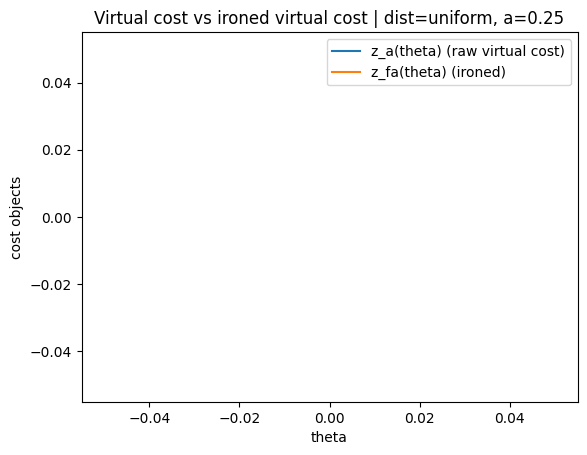

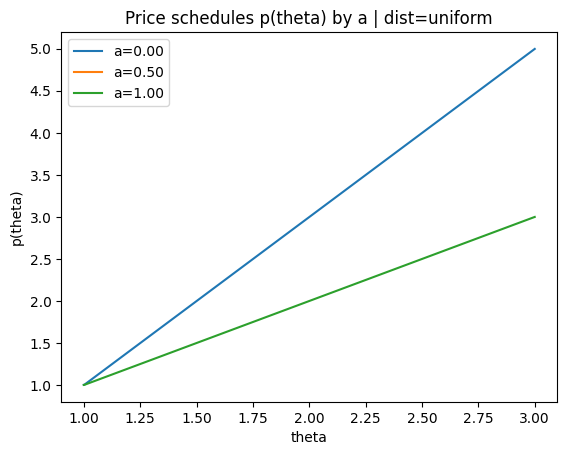

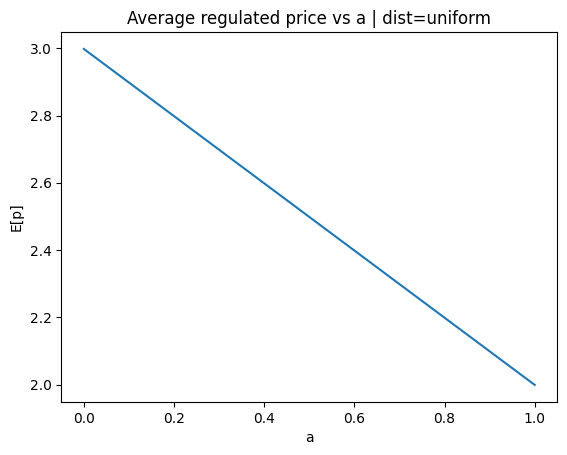

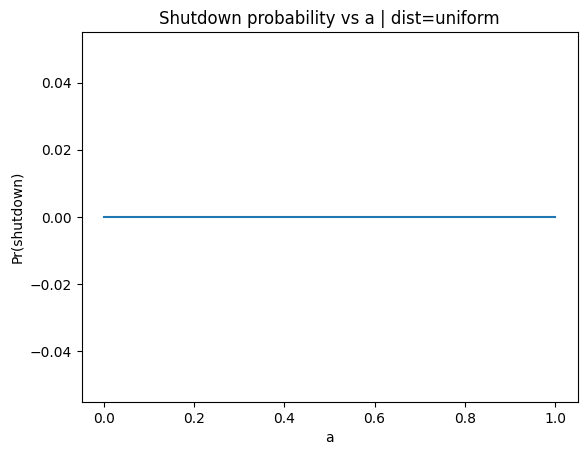

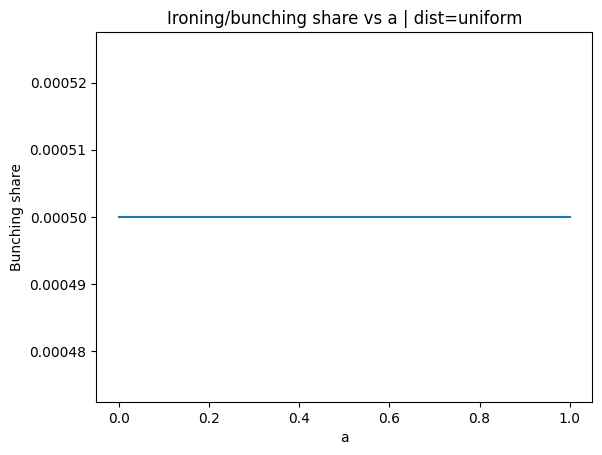

In [27]:
def plot_virtual_costs(df, dist_name, a_weight):
    # Filter
    sub = df[(df["dist"] == dist_name) & (np.isclose(df["a"], a_weight))]
    th = sub["theta"].to_numpy()
    za = sub["za"].to_numpy()
    zfa = sub["zfa"].to_numpy()

    plt.figure()
    plt.plot(th, za, label="z_a(theta) (raw virtual cost)")
    plt.plot(th, zfa, label="z_fa(theta) (ironed)")
    plt.xlabel("theta")
    plt.ylabel("cost objects")
    plt.title(f"Virtual cost vs ironed virtual cost | dist={dist_name}, a={a_weight}")
    plt.legend()
    plt.show()


def plot_price_schedules(df, dist_name, a_list):
    plt.figure()
    for a_weight in a_list:
        sub = df[(df["dist"] == dist_name) & (np.isclose(df["a"], a_weight))]
        th = sub["theta"].to_numpy()
        p = sub["p"].to_numpy()
        plt.plot(th, p, label=f"a={a_weight:.2f}")
    plt.xlabel("theta")
    plt.ylabel("p(theta)")
    plt.title(f"Price schedules p(theta) by a | dist={dist_name}")
    plt.legend()
    plt.show()


def plot_aggregates(df, dist_name):
    # One row per (dist,a) would be cleaner; we can take first per group
    grp = df[df["dist"] == dist_name].groupby(["dist", "a"], as_index=False).first()

    plt.figure()
    plt.plot(grp["a"], grp["E_p"])
    plt.xlabel("a")
    plt.ylabel("E[p]")
    plt.title(f"Average regulated price vs a | dist={dist_name}")
    plt.show()

    plt.figure()
    plt.plot(grp["a"], grp["Pr_shutdown"])
    plt.xlabel("a")
    plt.ylabel("Pr(shutdown)")
    plt.title(f"Shutdown probability vs a | dist={dist_name}")
    plt.show()

    plt.figure()
    plt.plot(grp["a"], grp["bunching_share"])
    plt.xlabel("a")
    plt.ylabel("Bunching share")
    plt.title(f"Ironing/bunching share vs a | dist={dist_name}")
    plt.show()


# --- Example plots ---
plot_virtual_costs(df, dist_name="uniform", a_weight=0.25)

plot_price_schedules(df, dist_name="uniform", a_list=[0.0, 0.5, 1.0])

plot_aggregates(df, dist_name="uniform")


In [53]:
def profit_true_report(theta_true, theta_report_grid, policy, cost_params):
    r"""
    LaTeX (raw):
        \pi(\theta,\hat\theta)
        =
        \left(p(\hat\theta)q(\hat\theta) - (c_0+c_1\theta)q(\hat\theta) - (k_0+k_1\theta)\right) r(\hat\theta)
        + s(\hat\theta)
    """
    c0, c1, k0, k1 = cost_params

    # arrays indexed by report type
    p = np.asarray(policy["p"])
    q = np.asarray(policy["q"])
    r = np.asarray(policy["r"])
    s = np.asarray(policy["s"])

    theta_true = float(theta_true)

    return (p*q - (c0 + c1*theta_true)*q - (k0 + k1*theta_true))*r + s


In [56]:
def truth_telling_profit_plot(policy, theta_grid, cost_params, true_types=None, n_true=3):
    r"""
    LaTeX (raw):
        \pi(\theta_{\text{true}},\hat\theta)
        =
        \left(p(\hat\theta)q(\hat\theta) - (c_0+c_1\theta_{\text{true}})q(\hat\theta) - (k_0+k_1\theta_{\text{true}})\right) r(\hat\theta)
        + s(\hat\theta)
    Goal:
        For each chosen true type, plot profit as a function of reported type.
        Under truth-telling IC, each curve peaks at \hat\theta=\theta_true.
    """
    theta_grid = np.asarray(theta_grid, dtype=float)

    # Choose default true types: low, mid, high
    if true_types is None:
        theta0 = float(theta_grid.min())
        theta1 = float(theta_grid.max())
        theta_mid = 0.5 * (theta0 + theta1)
        true_types = [theta0, theta_mid, theta1]
    else:
        # Ensure list-like
        true_types = list(true_types)

    # Compute profit curves for each true type over all reports
    plt.figure()
    for theta_true in true_types:
        # Profit for this true theta over all reported thetas (full curve)
        prof = profit_matrix_true_report(theta_true, theta_grid, policy, cost_params)

        # Identify argmax report on the grid
        j_star = int(np.argmax(prof))
        theta_star = theta_grid[j_star]
        prof_star = prof[j_star]

        # Plot curve
        plt.plot(theta_grid, prof, label=fr"$\theta_{{true}}={theta_true:.3f}$")

        # Mark the maximum point
        plt.scatter([theta_star], [prof_star], s=30)

        # Mark the truthful report location
        # (nearest grid point to theta_true)
        j_truth = int(np.argmin(np.abs(theta_grid - theta_true)))
        plt.axvline(theta_grid[j_truth], linestyle="--", linewidth=1)

    plt.xlabel(r"reported type $\hat{\theta}$")
    plt.ylabel(r"profit $\pi(\theta_{true},\hat{\theta})$")
    plt.title("Truth-Telling Plot: Profit vs reported type (peaks should be at truth)")
    plt.legend()
    plt.show()


In [ ]:
truth_telling_profit_plot(
    policy=out,
    theta_grid=theta_grid,
    cost_params=cost_params
)


TypeError: profit_matrix_true_report() takes 3 positional arguments but 4 were given

<Figure size 640x480 with 0 Axes>